In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.preprocessing import LabelEncoder

# 1 EXTRAÇÃO
df_base_interna = pd.read_csv('bases/base_interna.csv')

#Inicialização do LabelEncoder por coluna
le_bairro= LabelEncoder();
le_tipo_quarto= LabelEncoder();
le_tipo_propriedade= LabelEncoder();

# 2. TRANSFORMAÇÃO - SELEÇÃO DE COLUNAS para TRATAMENTO (Limpeza Bruta)
colunas_tratamento = ["price","accommodates","bedrooms", "beds", "bathrooms_text", 
"room_type", "review_scores_rating","minimum_nights", "number_of_reviews", "property_type",
"latitude", "longitude", "neighbourhood_cleansed"]
df_base_interna = df_base_interna[colunas_tratamento]

df_base_interna ["ano"] = 2025
df_base_interna ["mes"] = 9

# TRATAMENTO DA COLUNA 'price'
# RENOMEAR COLUNA 'price' PARA 'preco'
df_base_interna.rename(
    columns={'price': 'preco'},
    inplace=True
)
df_base_interna ['preco'] = df_base_interna ['preco'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
# df_base_interna [df_base_interna ['preco'].notnull()]

# TRATAMENTO DA COLUNA 'preco' PARA float
df_base_interna ['preco'] = df_base_interna ['preco'].astype(float)

In [5]:
# TRATAMENTO DA COLUNA 'accommodates'
# RENOMEAR COLUNA 'accommodates' PARA 'hospedes'
df_base_interna.rename(
    columns={'accommodates': 'hospedes'},
    inplace=True
)


#TRATAMENTO DA COLUNA 'bathrooms_text'
# CRIAR COLUNA 'banheiros' A PARTIR DA COLUNA 'bathrooms_text'
df_base_interna['banheiros'] = (
    df_base_interna['bathrooms_text']
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)

# REMOVER COLUNA 'bathrooms_text' APÓS EXTRAÇÃO DE INFORMAÇÃO
df_base_interna.drop('bathrooms_text', axis=1, inplace=True)


# TRATAMENTO DA CULUNA 'bedrooms'
# RENOMEAR COLUNA 'bedrooms' PARA 'quartos'
df_base_interna.rename(
    columns={'bedrooms': 'quartos'},
    inplace=True
)

# TRATAMENTO DA COLUNA 'beds'
# RENOMEAR COLUNA 'beds' PARA 'camas'
df_base_interna.rename(
    columns={'beds': 'camas'},
    inplace=True
)

# TRATAMENTO DA COLUNA 'room_type'
# RENOMEAR COLUNA 'room_type' PARA 'tipo_de_quarto'
df_base_interna.rename(
    columns={'room_type': 'tipo_de_quarto'},
    inplace=True
)
#Normalizar tipo_de_quarto - todos valores minúsculos
df_base_interna['tipo_de_quarto'] = (
    df_base_interna['tipo_de_quarto']
    .str.strip()
    .str.lower()
)

#LAbel encoder para 'tipo_de_quarto'
#df_base_interna ["tipo_de_quarto_encode"] = le_tipo_quarto.fit_transform(df_base_interna ["tipo_de_quarto"]) + 1

# # TRATAR VALORES NULOS - SUBSTITUIR POR 'moda'
# df_base_interna['tipo_de_quarto'] = (
#     df_base_interna['tipo_de_quarto'].fillna(df_base_interna['tipo_de_quarto'].mode()[0])
# )

# df_base_interna = pd.get_dummies(
#     df_base_interna,
#     columns=['tipo_de_quarto'],
#     prefix='tipo_quarto',
#     drop_first=False
# )

In [8]:
# TRATAMENTO DA COLUNA 'review_scores_rating'
# RENOMEAR COLUNA 'review_scores_rating' PARA 'nota_avaliacao'
df_base_interna.rename(
    columns={'review_scores_rating': 'nota_avaliacao'},
    inplace=True
)

# TRATAMENTO DA COLUNA 'minimum_nights'
# RENOMEAR COLUNA 'minimum_nights' PARA 'noites_minimas'
df_base_interna.rename(
    columns={'minimum_nights': 'noites_minimas'},
    inplace=True
)

# TRATAMENTO DA COLUNA 'number_of_reviews'
# RENOMEAR PARA 'quantidade_avaliacoes'
df_base_interna.rename(
    columns={'number_of_reviews': 'quantidade_avaliacoes'},
    inplace=True
)

# GARANTIR CONVERSÃO PARA NÚMERO
df_base_interna['quantidade_avaliacoes'] = pd.to_numeric(
    df_base_interna['quantidade_avaliacoes'],
    errors='coerce'
)

# TRATAMENTO DA COLUNA 'property_type'
# RENOMEAR COLUNA 'property_type' PARA 'tipo_de_propriedade'
df_base_interna.rename(
    columns={'property_type': 'tipo_de_propriedade'},
    inplace=True
)

# DEFINIR A COLUNA DE PROPRIEDADE PARA TRATAMENTO
coluna_propriedade = "tipo_de_propriedade"

# NORMALIZAÇÃO
df_base_interna[coluna_propriedade] = (
    df_base_interna[coluna_propriedade]
    .fillna("outros")
    .astype(str)
    .str.strip()
    .str.lower()
)

# MAPA DE AGRUPAMENTO (REGRA DE NEGÓCIO)
mapa_agrupamento = {

    # ESPAÇO INTEIRO – RESIDENCIAL
    "entire home": "espaco_inteiro_residencial",
    "entire condo": "espaco_inteiro_residencial",
    "entire rental unit": "espaco_inteiro_residencial",
    "entire guesthouse": "espaco_inteiro_residencial",
    "entire guest suite": "espaco_inteiro_residencial",
    "entire townhouse": "espaco_inteiro_residencial",
    "entire cottage": "espaco_inteiro_residencial",
    "entire bungalow": "espaco_inteiro_residencial",
    "entire villa": "espaco_inteiro_residencial",
    "entire vacation home": "espaco_inteiro_residencial",
    "entire serviced apartment": "espaco_inteiro_residencial",
    "entire loft": "espaco_inteiro_residencial",
    "entire chalet": "espaco_inteiro_residencial",
    "entire place": "espaco_inteiro_residencial",
    "tiny home": "espaco_inteiro_residencial",

    # QUARTO PRIVATIVO – RESIDENCIAL
    "private room": "quarto_privativo_residencial",
    "private room in home": "quarto_privativo_residencial",
    "private room in condo": "quarto_privativo_residencial",
    "private room in rental unit": "quarto_privativo_residencial",
    "private room in townhouse": "quarto_privativo_residencial",
    "private room in villa": "quarto_privativo_residencial",
    "private room in cabin": "quarto_privativo_residencial",
    "private room in guest suite": "quarto_privativo_residencial",
    "private room in farm stay": "quarto_privativo_residencial",
    "private room in casa particular": "quarto_privativo_residencial",

    # HOSPEDAGEM COMERCIAL
    "room in hotel": "hospedagem_comercial",
    "room in boutique hotel": "hospedagem_comercial",
    "private room in bed and breakfast": "hospedagem_comercial",
    "private room in hostel": "hospedagem_comercial",
    "shared room in hostel": "hospedagem_comercial",

}

# APLICAR AGRUPAMENTO
df_base_interna["tipo_de_propriedade_grupo"] = (
    df_base_interna[coluna_propriedade]
    .map(mapa_agrupamento)
    .fillna("outros")
)

# CRIAR VARIÁVEIS DO LABEL ENCODER PARA 'tipo_de_propriedade_grupo'
df_base_interna ["tipo_de_propriedade_grupo"] = le_tipo_propriedade.fit_transform(df_base_interna ["tipo_de_propriedade_grupo"]) + 1

# TRATAMENTO DA COLUNA 'latitude'
# TRATAMENTO DA COLUNA 'latitude' PARA float
df_base_interna ['latitude'] = df_base_interna ['latitude'].astype(float)

# TRATAMENTO DA COLUNA 'longitude'
# TRATAMENTO DA COLUNA 'longitude' PARA float
df_base_interna ['longitude'] = df_base_interna ['longitude'].astype(float)

# TRATAMENTO DA COLUNA "neighbourhood_cleansed"
# RENOMEAR COLUNA 'neighbourhood_cleansed' PARA 'bairro'
df_base_interna.rename(
    columns={'neighbourhood_cleansed': 'bairro'},
    inplace=True
)
# CRIAR VARIÁVEIS DO LABEL ENCODER 'bairro_grupo'
df_base_interna ["bairro_encode"] = le_bairro.fit_transform(df_base_interna ["bairro"]) + 1

In [12]:
conexao = sqlite3.connect('base_tratada.db')
df = pd.read_sql('SELECT * FROM base_tratada', conexao)

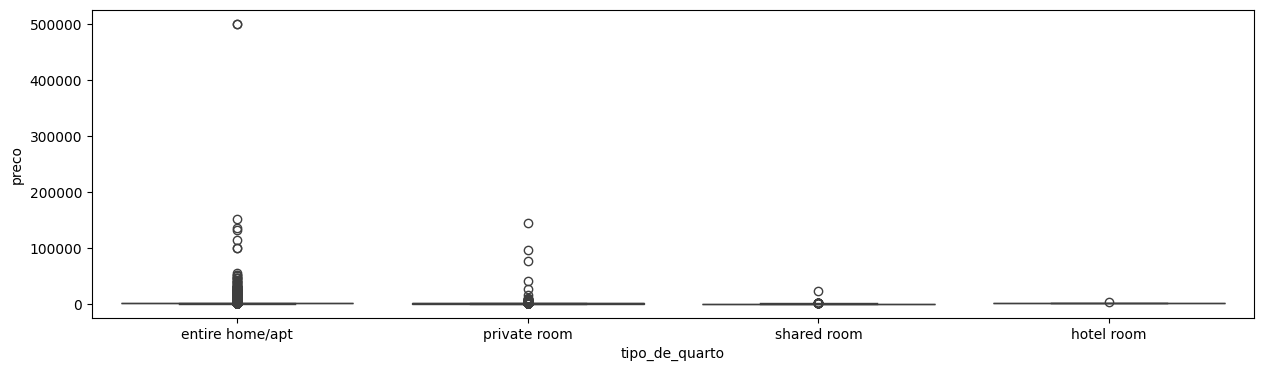

In [ ]:
# df_base_interna.columns
plt.figure(figsize=(15,4))
 
sns.boxplot(y='preco',x = 'tipo_de_quarto',data=df)
plt.show()